In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import numpy as np
import util
import os
import time
import pprint
from math import ceil, floor
import matplotlib.pyplot as plt
import plotting as plotting
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from problem import State, Action, Request, ServiceWindow, PntSchedulingProblem, reset_id_counters
pp = pprint.PrettyPrinter()
figures_path = "../figures/AA229/"


# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Toy Problem

[Request(user_id=0, start=0, end=10, duration=2, priority=1, arrival=0, id=0),
 Request(user_id=1, start=0, end=10, duration=2, priority=1, arrival=0, id=1),
 Request(user_id=1, start=0, end=10, duration=3, priority=1, arrival=3, id=2),
 Request(user_id=2, start=0, end=10, duration=2, priority=1, arrival=0, id=3),
 Request(user_id=3, start=0, end=10, duration=2, priority=1, arrival=3, id=4)]
[Request(user_id=0, start=0, end=10, duration=2, priority=1, arrival=0, id=0),
 Request(user_id=1, start=0, end=10, duration=2, priority=1, arrival=0, id=1),
 Request(user_id=1, start=0, end=10, duration=3, priority=1, arrival=3, id=2),
 Request(user_id=2, start=0, end=10, duration=2, priority=1, arrival=0, id=3),
 Request(user_id=3, start=0, end=10, duration=2, priority=1, arrival=3, id=4)]


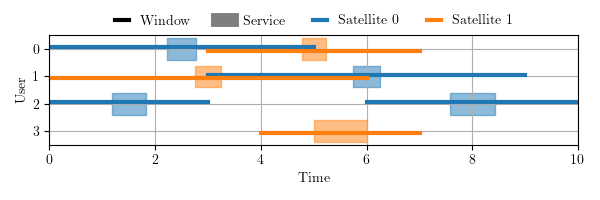

In [80]:
reset_id_counters()
requests = [
    Request(user_id=0, start=0, end=10, duration=2, arrival=0),
    Request(user_id=1, start=0, end=10, duration=2, arrival=0),
    Request(user_id=1, start=0, end=10, duration=3, arrival=3),
    Request(user_id=2, start=0, end=10, duration=2, arrival=0),
    Request(user_id=3, start=0, end=10, duration=2, arrival=3),
]
pp.pprint(requests)
N_req = len(requests)
request_dict = {r.id: r for r in requests}

service_windows = [
    # Satellite 0
    ServiceWindow(user_id=0, satellite_id=0, start=0, end=5),
    ServiceWindow(user_id=1, satellite_id=0, start=3, end=9),
    ServiceWindow(user_id=2, satellite_id=0, start=0, end=3),
    ServiceWindow(user_id=2, satellite_id=0, start=6, end=10),
    # ServiceWindow(user_id=3, satellite_id=0, start=6, end=10),
    # Satellite 1
    ServiceWindow(user_id=0, satellite_id=1, start=3, end=7),
    ServiceWindow(user_id=1, satellite_id=1, start=0, end=6),
    ServiceWindow(user_id=3, satellite_id=1, start=4, end=7),
]
pp.pprint(requests)
N_win = len(service_windows)
N_sat = 2

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times = np.ones((N_sat, N_req, N_req))
for i in range(N_sat):
    transition_times[i, np.diag_indices(N_req)] = 0
transition_times[0, :] = 0
transition_times[:, 0] = 0
data_gen_func = lambda ts, te: -0.5 * (te - ts)
energy_gen_func = lambda ts, te: 0.5 * (te - ts)


time_step = 1
CN0 = np.ones((2, len(requests) - 1, 10 * time_step))

problem = PntSchedulingProblem(
    time_step=time_step,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    max_energy=15,
    min_energy=2,
    max_data=15,
    min_data=2,
    payload_data_gen=1,
    payload_power_gen=-1,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)
plt.tight_layout()

In [81]:
# Forward search
d = 6
gamma = 0.7
N_max = 5
d_min = 10
problem.set_current_time(0)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 2.96
Percentage of requests served:
[100.0, 100.0, nan, 100.0, nan]
Total: 2.96


Total reward: 2.96


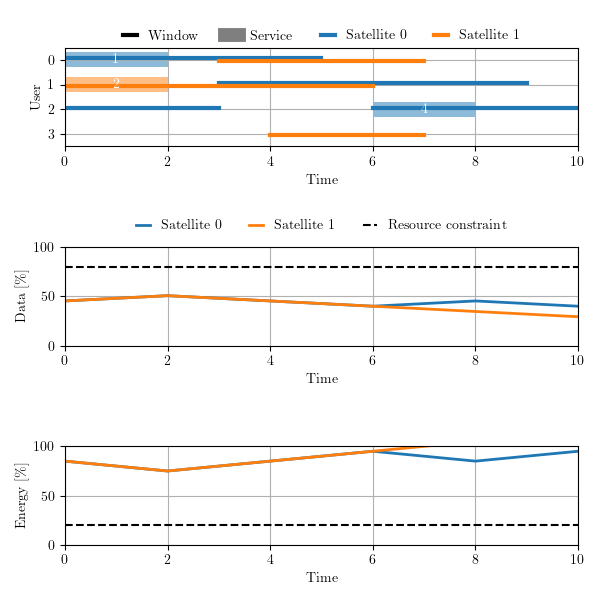

In [82]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [83]:
old_policy = policy

In [84]:
arrival_times = sorted(list(set([r.arrival for r in requests])))
arrival_times

[0, 3]

In [85]:
# Minimum energy and maximum data at start time of a given action
required_resources = dict[Action, tuple[float, float]]()
for sat_id in range(N_sat):
    actions = [
        a
        for s, a in policy[::-1]
        if a is not None and a.request is not None and a.satellite_id == sat_id
    ]
    e = problem.min_energy
    d = problem.max_data
    a = actions[0]
    t_prev = a.start + a.duration
    for a in actions:
        # Energy and data from start to end of action
        e += problem.payload_data_gen * a.duration
        d -= problem.payload_power_gen * a.duration
        
        # Energy and data from start of action to start of the next
        e -= problem.data_gen_func(a.start, t_prev)
        d += problem.energy_gen_func(a.start, t_prev)

        required_resources[a] = (e, d)
        t_prev = a.start
        
required_resources

{Action(sat=0, usr=2, req=3, start=6.00, dur=2.00): (5.0, 18.0),
 Action(sat=0, usr=0, req=0, start=0.00, dur=2.00): (10.0, 23.0),
 Action(sat=1, usr=1, req=1, start=0.00, dur=2.00): (5.0, 18.0)}

In [90]:
policy

[(State(t=[0. 0.], d=[8.5 8.5], e=[8.5 8.5], req=[0.0, 0.0, 0.0, 0.0, 0.0]),
  Action(sat=0, usr=0, req=0, start=0.00, dur=2.00)),
 (State(t=[2. 0.], d=[9.5 8.5], e=[7.5 8.5], req=[2.0, 0.0, 0.0, 0.0, 0.0]),
  Action(sat=1, usr=1, req=1, start=0.00, dur=2.00)),
 (State(t=[2. 2.], d=[9.5 9.5], e=[7.5 7.5], req=[2.0, 2.0, 0.0, 0.0, 0.0]),
  Action(sat=1, usr=None, req=None, start=2.00, dur=8.00)),
 (State(t=[ 2. 10.], d=[9.5 5.5], e=[ 7.5 11.5], req=[2.0, 2.0, 0.0, 0.0, 0.0]),
  Action(sat=0, usr=2, req=3, start=6.00, dur=2.00)),
 (State(t=[ 8. 10.], d=[8.5 5.5], e=[ 8.5 11.5], req=[2.0, 2.0, 0.0, 2.0, 0.0]),
  Action(sat=0, usr=None, req=None, start=8.00, dur=2.00)),
 (State(t=[10. 10.], d=[7.5 5.5], e=[ 9.5 11.5], req=[2.0, 2.0, 0.0, 2.0, 0.0]),
  None)]

In [91]:
problem.set_current_time(3)
problem.set_current_policy(old_policy)
problem.initial_state()

State(t=[2. 2.], d=[9.5 9.5], e=[7.5 7.5], req=[2.0, 2.0, 0.0, 0.0, 0.0])

In [92]:
# Forward search
d = 6
gamma = 0.7
N_max = 5
d_min = 10
problem.set_current_time(3)
problem.set_current_policy(old_policy)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 1.51
Percentage of requests served:
[100.0, 100.0, 100.0, 50.0, 100.0]
Total: 1.51


Total reward: 1.51


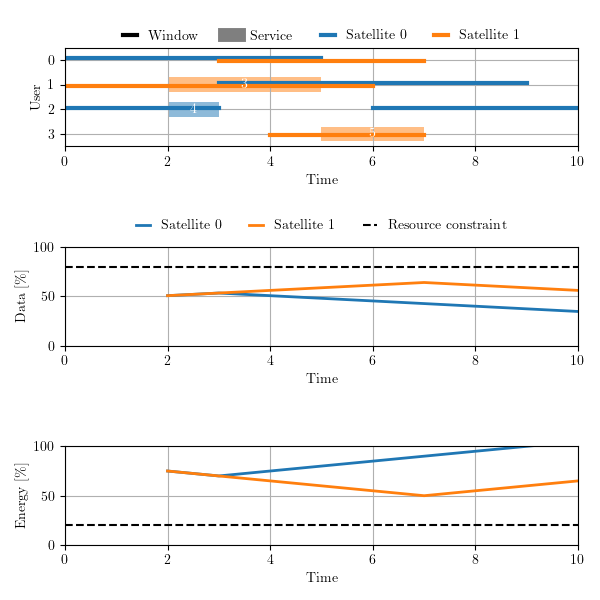

In [93]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [95]:
idx = problem.get_current_policy_index()
merged_policy = old_policy[:idx] + policy

Total reward: 4.31


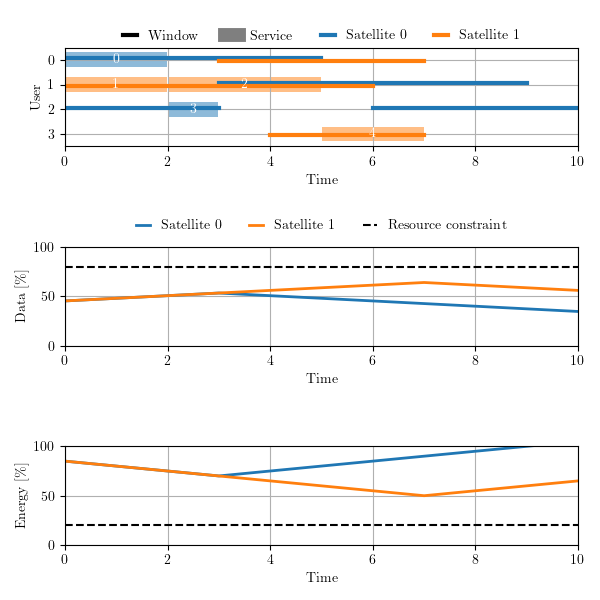

In [99]:
policy = merged_policy
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [101]:
[(t,s,a) for t, (s,a) in enumerate(merged_policy)]

[(0,
  State(t=[0. 0.], d=[8.5 8.5], e=[8.5 8.5], req=[0.0, 0.0, 0.0, 0.0, 0.0]),
  Action(sat=0, usr=0, req=0, start=0.00, dur=2.00)),
 (1,
  State(t=[2. 0.], d=[9.5 8.5], e=[7.5 8.5], req=[2.0, 0.0, 0.0, 0.0, 0.0]),
  Action(sat=1, usr=1, req=1, start=0.00, dur=2.00)),
 (2,
  State(t=[2. 2.], d=[9.5 9.5], e=[7.5 7.5], req=[2.0, 2.0, 0.0, 0.0, 0.0]),
  Action(sat=0, usr=2, req=3, start=2.00, dur=1.00)),
 (3,
  State(t=[3. 2.], d=[10.   9.5], e=[7.  7.5], req=[2.0, 2.0, 0.0, 1.0, 0.0]),
  Action(sat=1, usr=1, req=2, start=2.00, dur=3.00)),
 (4,
  State(t=[3. 5.], d=[10. 11.], e=[7. 6.], req=[2.0, 2.0, 3.0, 1.0, 0.0]),
  Action(sat=0, usr=None, req=None, start=3.00, dur=7.00)),
 (5,
  State(t=[10.  5.], d=[ 6.5 11. ], e=[10.5  6. ], req=[2.0, 2.0, 3.0, 1.0, 0.0]),
  Action(sat=1, usr=3, req=4, start=5.00, dur=2.00)),
 (6,
  State(t=[10.  7.], d=[ 6.5 12. ], e=[10.5  5. ], req=[2.0, 2.0, 3.0, 1.0, 2.0]),
  Action(sat=1, usr=None, req=None, start=7.00, dur=3.00)),
 (7,
  State(t=[10. 10.]

In [103]:
s, a = merged_policy[4]

In [104]:
problem.available_actions(s, N_max, d_min)

[Action(sat=0, usr=None, req=None, start=3.00, dur=7.00),
 Action(sat=0, usr=2, req=3, start=6.00, dur=1.00)]

In [134]:
# MCTS
d = 5
gamma = 0.9
n = int(1e3)
c = 10
N_max = 5
d_min = 1
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, n=n, c=c, N_max=N_max, d_min=d_min)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

AttributeError: 'State' object has no attribute 'time'

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Apr 04 02:23:38 PM: Your problem has 80 variables, 291 constraints, and 0 parameters.
(CVXPY) Apr 04 02:23:38 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 04 02:23:38 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 04 02:23:38 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 04 02:23:38 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Compiling problem (target solver=GUROBI).


(CVXPY) Apr 04 02:23:38 PM: Applying reduction QpMatrixStuffing
(CVXPY) Apr 04 02:23:38 PM: Applying reduction GUROBI
(CVXPY) Apr 04 02:23:38 PM: Finished problem compilation (took 6.473e-02 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Invoking solver GUROBI  to obtain a solution.
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-11
Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D60)

CPU model: Apple M3 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 574 rows, 152 columns and 1848 nonzeros
Model fingerprint: 0x1f80aef1
Variable types: 72 continuous, 80 integer (80 binary)
Coefficient statistics:
  

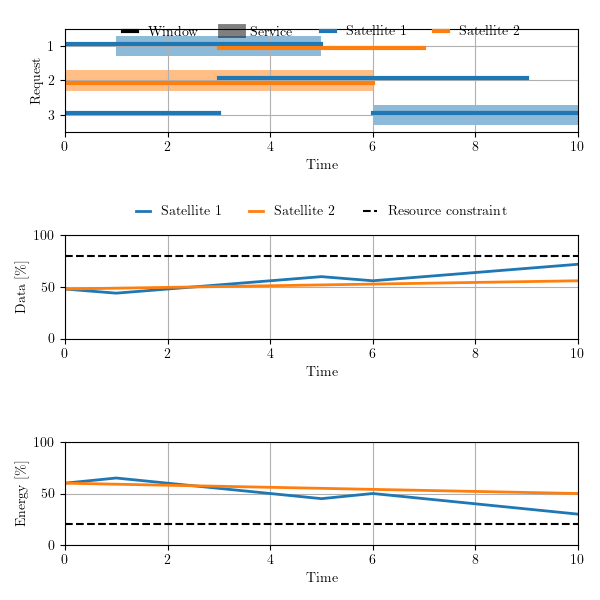

In [ ]:
# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step_factor=1)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()